# HomeWork -4
## Objective
 In this homework, you will design a python class that encapsulates common univariate/bivariate analysis tasks. You will practice object oriented programing (OOP) while applying descriptive statistics and visualization to summarize your data and explore the relationship between two variables. 
 
 - Use the example provided in the class activity and expand it. The initializer of the class should take data and print out its shape and column names. 
 - Additionally, your class should include at least 5 methods (function) to do either univariate or bivariate analysis of your choice. 
 - Provide markdowns or comments for each part of your code.  

  - Create an instance of your class using Penguin data and use it to analyze it.
  
  - For each analysis you perform, write 1-2 sentence before that function call that clearly state
    the question you are trying to answer with that analysis. For example: "In this analysis I want to see what is the average mass for each species." 

  


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [16]:
class BivariateAnalyzer:
    """ 
    A comprehensive toolkit for Univariate and Bivariate Data Analysis 
    """
    def __init__(self, data):
        self.df = data.copy()
        # Initializer
        print(f"Data Loaded: {self.df.shape[0]} rows, {self.df.shape[1]} columns")
        print(f"Columns: {list(self.df.columns)}\n" + "-"*30)
        
    # Method 1: Quantitative vs Quantitative
    def quant_quant(self, x, y):
        """Scatter plot with correlation coefficient."""
        corr = self.df[[x, y]].corr().iloc[0, 1].round(3)
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=self.df, x=x, y=y, alpha=0.7)
        plt.title(f"Scatter Plot: {x} vs {y} (Corr: {corr})")
        plt.show()
        return corr
    
    # Method 2: Categorical vs Quantitative
    def cat_quant(self, cat, quant, hue=None):
        """Boxplot to compare distributions across categories."""
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=self.df, x=cat, y=quant, hue=hue, palette="Set2")
        plt.title(f"Distribution of {quant} by {cat}")
        plt.show()
        means = self.df.groupby(cat)[quant].mean().round(2)
        print(f"Average {quant} per {cat}:\n{means}\n")
    
    # Method 3: Categorical vs Categorical
    def cat_cat(self, cat1, cat2):
        """Heatmap of counts to see the relationship between two categories."""
        ct = pd.crosstab(self.df[cat1], self.df[cat2])
        plt.figure(figsize=(7, 4))
        sns.heatmap(ct, annot=True, fmt='d', cmap="YlGnBu")
        plt.title(f"Frequency: {cat1} vs {cat2}")
        plt.show()

    # Method 4: Univariate Quantitative
    def univariate_quant(self, col):
        """Histogram and KDE to see the distribution of a single numeric variable."""
        plt.figure(figsize=(8, 5))
        sns.histplot(self.df[col], kde=True, color="skyblue")
        plt.title(f"Univariate Analysis: {col} Distribution")
        plt.show()
        print(f"Stats for {col}:\n{self.df[col].describe()}\n")

    # Method 5: Univariate Categorical
    def univariate_cat(self, col):
        """Count plot to see the frequency of categories."""
        plt.figure(figsize=(8, 5))
        sns.countplot(data=self.df, x=col)
        plt.title(f"Count of Observations per {col}")
        plt.show()

In [17]:
penguins = sns.load_dataset("penguins").dropna()

# Creating the instance
analyzer = BivariateAnalyzer(penguins)

Data Loaded: 333 rows, 7 columns
Columns: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
------------------------------


### In this analysis, I want to see if penguins with longer flippers also tend to have longer bills by calculating their correlation coefficient. There seems to be a positive correlation.

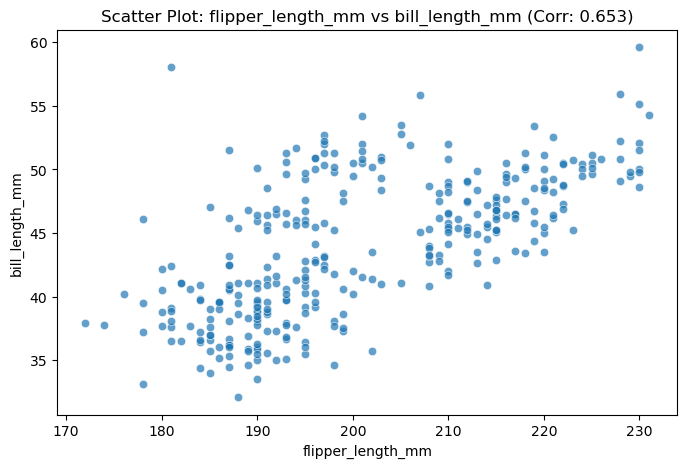

np.float64(0.653)

In [18]:
analyzer.quant_quant(x='flipper_length_mm', y='bill_length_mm')

### In this analysis, I want to see if the body mass differs across the three species and if there is also a difference between males and females.

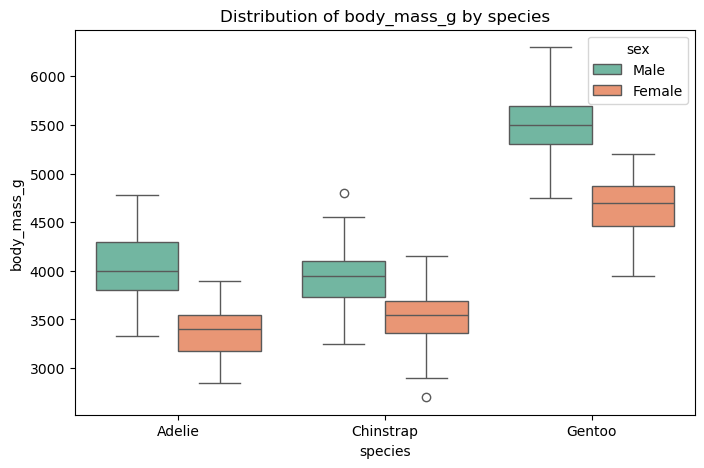

Average body_mass_g per species:
species
Adelie       3706.16
Chinstrap    3733.09
Gentoo       5092.44
Name: body_mass_g, dtype: float64



In [19]:
analyzer.cat_quant(cat="species", quant="body_mass_g", hue="sex")

### In this analysis, I want to see how the different species are distributed across the three islands and if species are localized to specific regions.

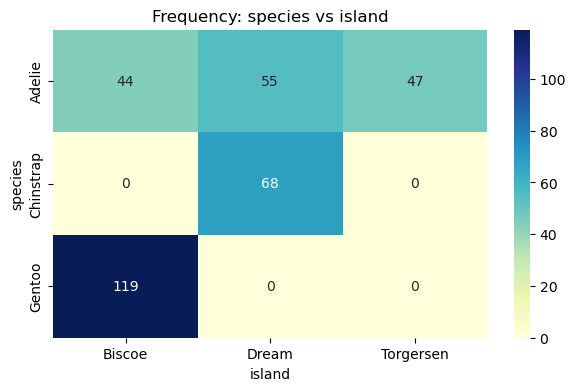

In [20]:
analyzer.cat_cat("species", "island")

### In this analysis, I want to see how the mass of all penguins are distributed to identify the most common weight range and check for any skewness. It looks to be right skewed.

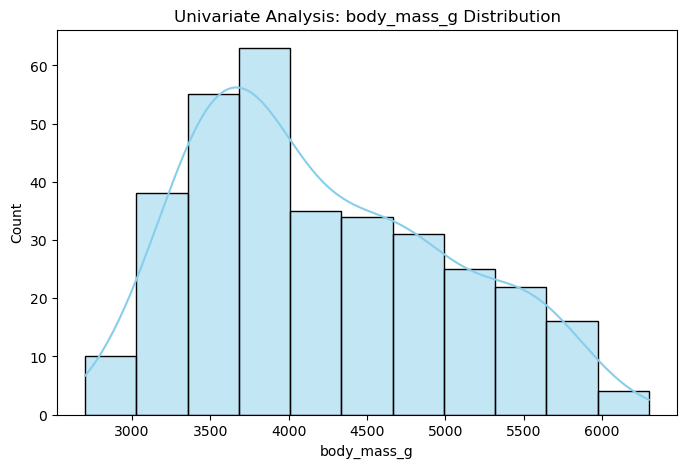

Stats for body_mass_g:
count     333.000000
mean     4207.057057
std       805.215802
min      2700.000000
25%      3550.000000
50%      4050.000000
75%      4775.000000
max      6300.000000
Name: body_mass_g, dtype: float64



In [21]:
analyzer.univariate_quant('body_mass_g')

### In this analysis, I want to see which penguin species is the most common in this dataset. It seems that Adelie is the most common.

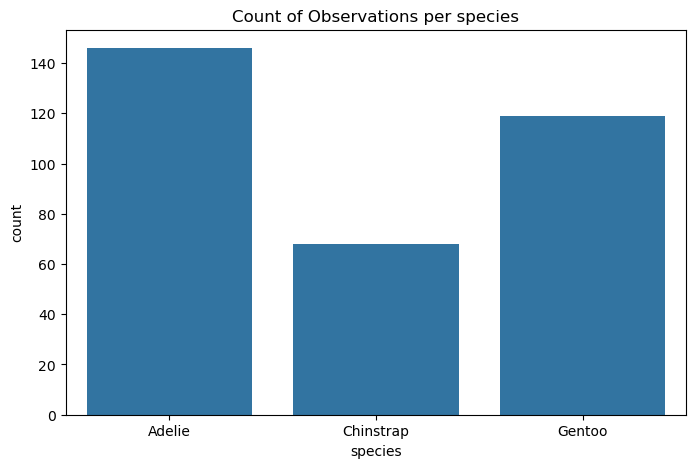

In [23]:
analyzer.univariate_cat("species")